In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import vgg19
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import matplotlib.pyplot as plt
import time

In [ ]:
ITER = 1000 #default is 1000
CONTENT_WEIGHT = 1 #default is 1
STYLE_WEIGHT = 1e6 #default is 1e6
CONTENT_IMG = "images/paris.jpg" #name of content image
STYLE_IMG = "vangogh/starry_night.jpg" #name of style image

In [ ]:
def find_between( s, first, last ):
    try:
        start = s.index( first ) + len( first )
        end = s.index( last, start )
        return s[start:end]
    except ValueError:
        return ""

In [ ]:
CONTENT_NAME = find_between(CONTENT_IMG, "/", ".")
STYLE_NAME = find_between(STYLE_IMG, "/", ".")

print(CONTENT_NAME, STYLE_NAME)

paris starry_night


In [ ]:
def load_and_process_image(path, max_dim=512):
    """Load and preprocess an image for VGG19."""
    img = load_img(path)

    # Resize image while preserving aspect ratio
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = tuple([int(dim * scale) for dim in img.size])
    img = img.resize(new_size)

    # Convert to array and add batch dimension
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for VGG19
    img_array = vgg19.preprocess_input(img_array)

    return img_array

In [ ]:
def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    x = processed_img.copy()

    # Remove batch dimension
    if len(x.shape) == 4:
        x = np.squeeze(x, axis=0)

    # Undo VGG preprocessing
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]  # Convert BGR to RGB

    # Clip to valid range
    x = np.clip(x, 0, 255).astype('uint8')

    return x

In [ ]:
def get_feature_representations(model, content_path, style_path, max_dim=512):
    """Extract content and style features from VGG19."""
    content_image = load_and_process_image(content_path, max_dim)
    style_image = load_and_process_image(style_path, max_dim)

    # Get feature representations
    content_outputs = model(content_image)
    style_outputs = model(style_image)

    # Extract content and style features
    content_features = [content_outputs[name] for name in content_layer_names]
    style_features = [style_outputs[name] for name in style_layer_names]

    return content_features, style_features, content_image

In [ ]:
def gram_matrix(input_tensor):
    """Calculate Gram matrix for style representation."""
    # Reshape the tensor
    channels = int(input_tensor.shape[-1])
    a = tf.reshape(input_tensor, [-1, channels])

    # Calculate gram matrix: G = F^T * F
    n = tf.shape(a)[0]
    gram = tf.matmul(a, a, transpose_a=True)

    # Normalize the values
    gram = gram / tf.cast(n, tf.float32)

    return gram

In [ ]:
def compute_content_loss(content_features, target_features):
    """Compute content loss as per the paper."""
    return tf.reduce_mean(tf.square(content_features - target_features))

In [ ]:
def compute_style_loss(style_features, target_features):
    """Compute style loss as per the paper."""
    target_gram = gram_matrix(target_features)
    style_gram = gram_matrix(style_features)

    return tf.reduce_mean(tf.square(style_gram - target_gram))

In [ ]:
def compute_total_loss(content_features, style_features, target_features, style_weight=STYLE_WEIGHT, content_weight=CONTENT_WEIGHT):
    """Compute the total loss - content and style."""
    style_score = 0
    content_score = 0

    # Content loss from the content layer
    content_score += compute_content_loss(
        target_features[content_layer_names[0]],
        content_features[0]
    )

    # Style loss from all style layers
    weight_per_style_layer = 1.0 / float(len(style_layer_names))
    for target_style, source_style in zip(
        [target_features[name] for name in style_layer_names],
        style_features
    ):
        style_score += weight_per_style_layer * compute_style_loss(source_style, target_style)

    # Weight the style and content loss
    style_score *= style_weight
    content_score *= content_weight

    # Total loss
    total_loss = style_score + content_score

    return total_loss, style_score, content_score

In [ ]:
@tf.function()
def train_step(image, content_features, style_features, optimizer,
               content_weight=CONTENT_WEIGHT, style_weight=STYLE_WEIGHT):
    """Perform one optimization step."""
    with tf.GradientTape() as tape:
        # Calculate features of current generated image
        outputs = model(image)
        target_features = {name: outputs[name] for name in outputs.keys()}

        # Compute loss
        loss, style_score, content_score = compute_total_loss(
            content_features, style_features, target_features,
            style_weight, content_weight
        )

    # Compute gradients
    grad = tape.gradient(loss, image)

    # Apply gradients
    optimizer.apply_gradients([(grad, image)])

    # Clip pixel values to valid range
    image.assign(tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=255.0))

    return loss, style_score, content_score

In [ ]:
def run_style_transfer(content_path, style_path,
                       content_weight=CONTENT_WEIGHT, style_weight=STYLE_WEIGHT,
                       iterations=ITER, max_dim=512):
    """Run the style transfer algorithm."""
    # Get feature representations
    content_features, style_features, content_image = get_feature_representations(
        model, content_path, style_path, max_dim
    )

    # Initialize the generated image from the content image
    generated_image = tf.Variable(content_image, dtype=tf.float32)

    # Create optimizer (Adam as recommended in the paper)
    optimizer = tf.optimizers.Adam(learning_rate=5.0)

    # Initialize progress tracking
    start_time = time.time()
    step = 0

    # Track best results
    best_loss, best_img = float('inf'), None

    # Optimization loop
    for step in range(iterations):
        loss, style_score, content_score = train_step(
            generated_image, content_features, style_features,
            optimizer, content_weight, style_weight
        )

        if loss < best_loss:
            best_loss = loss
            best_img = generated_image.numpy()

        # Print progress
        if step % 100 == 0:
            print(f"Iteration: {step}")
            print(f"Total loss: {loss:.4e}, "
                  f"Style loss: {style_score:.4e}, "
                  f"Content loss: {content_score:.4e}")
            print(f"Time elapsed: {time.time() - start_time:.2f}s")

    # Return the best image
    return deprocess_image(best_img)

In [ ]:
# Define content and style layers according to the paper
content_layer_names = ['block4_conv2']
style_layer_names = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# Load VGG19 model
vgg = vgg19.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

In [ ]:
# Create intermediate model that outputs layer activations
outputs = {}
for name in content_layer_names + style_layer_names:
    outputs[name] = vgg.get_layer(name).output
model = tf.keras.Model(vgg.input, outputs)

In [ ]:
content_path = f"drive/MyDrive/Intro CV/Final Project/CV Final Project/code/dataset/{CONTENT_IMG}"  # Replace with your content image path
style_path = f"drive/MyDrive/Intro CV/Final Project/CV Final Project/code/dataset/{STYLE_IMG}"      # Replace with your style image path

In [ ]:
# Run style transfer
result_image = run_style_transfer(
    content_path=content_path,
    style_path=style_path,
    content_weight=CONTENT_WEIGHT,       # Balance between content and style
    style_weight=STYLE_WEIGHT,       # Higher values prioritize style
    iterations=ITER,        # More iterations = better results but slower
    max_dim=512            # Maximum dimension of input images
)

Iteration: 0
Total loss: 3.4749e+16, Style loss: 3.4749e+16, Content loss: 0.0000e+00
Time elapsed: 1.21s
Iteration: 100
Total loss: 1.8823e+14, Style loss: 1.8823e+14, Content loss: 6.3635e+05
Time elapsed: 7.24s
Iteration: 200
Total loss: 1.0113e+14, Style loss: 1.0113e+14, Content loss: 6.5586e+05
Time elapsed: 13.26s
Iteration: 300
Total loss: 7.2750e+13, Style loss: 7.2750e+13, Content loss: 6.6746e+05
Time elapsed: 19.29s
Iteration: 400
Total loss: 5.8428e+13, Style loss: 5.8428e+13, Content loss: 6.7435e+05
Time elapsed: 25.36s
Iteration: 500
Total loss: 4.9587e+13, Style loss: 4.9587e+13, Content loss: 6.7907e+05
Time elapsed: 31.44s
Iteration: 600
Total loss: 4.6941e+13, Style loss: 4.6941e+13, Content loss: 6.8183e+05
Time elapsed: 37.51s
Iteration: 700
Total loss: 3.9569e+13, Style loss: 3.9569e+13, Content loss: 6.8619e+05
Time elapsed: 43.59s
Iteration: 800
Total loss: 3.5665e+13, Style loss: 3.5665e+13, Content loss: 6.8871e+05
Time elapsed: 49.69s
Iteration: 900
Total lo

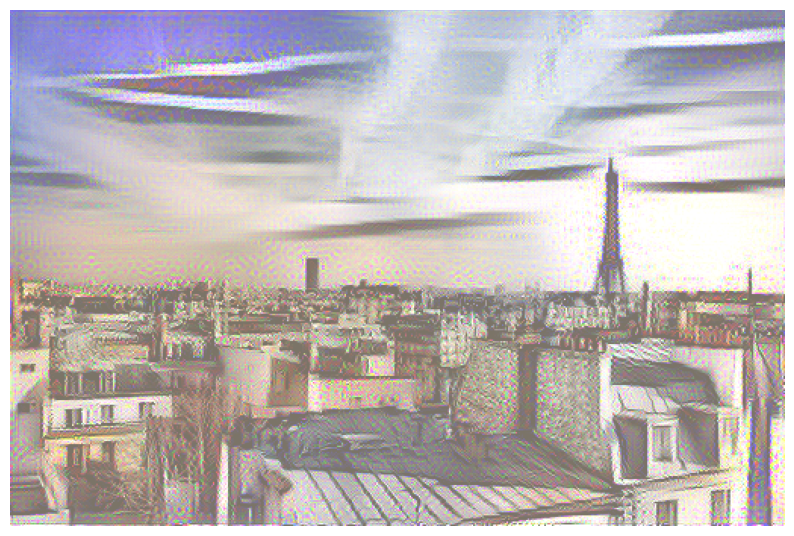

In [ ]:
# Display result
plt.figure(figsize=(10, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()

In [ ]:
# Save result
array_to_img(result_image).save(f"drive/MyDrive/Intro CV/Final Project/CV Final Project/code/result/{CONTENT_NAME}_{STYLE_NAME}_CW{CONTENT_WEIGHT}_SW{STYLE_WEIGHT}.jpg")
print("Style transfer complete! Image saved.")

Style transfer complete! Image saved.


In [ ]:
def run_loop(content_imgs, style_imgs, content_style_weights, iterations):
  """
  content_imgs = ["images/paris.jpg", "images/portrait.jpg", "images/portrait2.jpg", "images/still.jpg"]
  style_imgs = ["modern/close.jpg", "modern/dali.jpg", "modern/pollock.jpg", "modern/warhol.jpg", "modern/kandinsky.jpg", "modern/wave.jpg",
  "modern/mondrian.jpg", "modern/klimt.jpg", "modern/bosch.jpg", "modern/lichtenstein.jpg", "modern/chagall.jpg"]
  content_style_weights = [[1e4, 1], [1e2, 1], [1e3, 1], [1, 1], [1, 1e1], [1, 1e2], [1, 1e3], [1e6, 1]]
  """
  def find_between( s, first, last ):
    try:
        start = s.index( first ) + len( first )
        end = s.index( last, start )
        return s[start:end]
    except ValueError:
        return ""

  for c in content_imgs:
    CONTENT_IMG = c
    CONTENT_NAME = find_between(c, "/", ".")
    for s in style_imgs:
      STYLE_IMG = s
      STYLE_NAME = find_between(s, "/", ".")
      for cw, sw in content_style_weights:
        ITER = iterations
        CONTENT_WEIGHT = cw
        STYLE_WEIGHT = sw

        def load_and_process_image(path, max_dim=512):
            """Load and preprocess an image for VGG19."""
            img = load_img(path)

            # Resize image while preserving aspect ratio
            long_dim = max(img.size)
            scale = max_dim / long_dim
            new_size = tuple([int(dim * scale) for dim in img.size])
            img = img.resize(new_size)

            # Convert to array and add batch dimension
            img_array = img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)

            # Preprocess for VGG19
            img_array = vgg19.preprocess_input(img_array)

            return img_array

        def deprocess_image(processed_img):
            """Convert processed image back to displayable format."""
            x = processed_img.copy()

            # Remove batch dimension
            if len(x.shape) == 4:
                x = np.squeeze(x, axis=0)

            # Undo VGG preprocessing
            x[:, :, 0] += 103.939
            x[:, :, 1] += 116.779
            x[:, :, 2] += 123.68
            x = x[:, :, ::-1]  # Convert BGR to RGB

            # Clip to valid range
            x = np.clip(x, 0, 255).astype('uint8')

            return x

        def get_feature_representations(model, content_path, style_path, max_dim=512):
            """Extract content and style features from VGG19."""
            content_image = load_and_process_image(content_path, max_dim)
            style_image = load_and_process_image(style_path, max_dim)

            # Get feature representations
            content_outputs = model(content_image)
            style_outputs = model(style_image)

            # Extract content and style features
            content_features = [content_outputs[name] for name in content_layer_names]
            style_features = [style_outputs[name] for name in style_layer_names]

            return content_features, style_features, content_image

        def gram_matrix(input_tensor):
            """Calculate Gram matrix for style representation."""
            # Reshape the tensor
            channels = int(input_tensor.shape[-1])
            a = tf.reshape(input_tensor, [-1, channels])

            # Calculate gram matrix: G = F^T * F
            n = tf.shape(a)[0]
            gram = tf.matmul(a, a, transpose_a=True)

            # Normalize the values
            gram = gram / tf.cast(n, tf.float32)

            return gram

        def compute_content_loss(content_features, target_features):
            """Compute content loss as per the paper."""
            return tf.reduce_mean(tf.square(content_features - target_features))

        def compute_style_loss(style_features, target_features):
            """Compute style loss as per the paper."""
            target_gram = gram_matrix(target_features)
            style_gram = gram_matrix(style_features)

            return tf.reduce_mean(tf.square(style_gram - target_gram))

        def compute_total_loss(content_features, style_features, target_features, style_weight=STYLE_WEIGHT, content_weight=CONTENT_WEIGHT):
            """Compute the total loss - content and style."""
            style_score = 0
            content_score = 0

            # Content loss from the content layer
            content_score += compute_content_loss(
                target_features[content_layer_names[0]],
                content_features[0]
            )

            # Style loss from all style layers
            weight_per_style_layer = 1.0 / float(len(style_layer_names))
            for target_style, source_style in zip(
                [target_features[name] for name in style_layer_names],
                style_features
            ):
                style_score += weight_per_style_layer * compute_style_loss(source_style, target_style)

            # Weight the style and content loss
            style_score *= style_weight
            content_score *= content_weight

            # Total loss
            total_loss = style_score + content_score

            return total_loss, style_score, content_score

        @tf.function()
        def train_step(image, content_features, style_features, optimizer,
                      content_weight=CONTENT_WEIGHT, style_weight=STYLE_WEIGHT):
            """Perform one optimization step."""
            with tf.GradientTape() as tape:
                # Calculate features of current generated image
                outputs = model(image)
                target_features = {name: outputs[name] for name in outputs.keys()}

                # Compute loss
                loss, style_score, content_score = compute_total_loss(
                    content_features, style_features, target_features,
                    style_weight, content_weight
                )

            # Compute gradients
            grad = tape.gradient(loss, image)

            # Apply gradients
            optimizer.apply_gradients([(grad, image)])

            # Clip pixel values to valid range
            image.assign(tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=255.0))

            return loss, style_score, content_score


        def run_style_transfer(content_path, style_path,
                                content_weight=CONTENT_WEIGHT, style_weight=STYLE_WEIGHT,
                                iterations=ITER, max_dim=512):
            """Run the style transfer algorithm."""
            # Get feature representations
            content_features, style_features, content_image = get_feature_representations(
                model, content_path, style_path, max_dim
            )

            # Initialize the generated image from the content image
            generated_image = tf.Variable(content_image, dtype=tf.float32)

            # Create optimizer (Adam as recommended in the paper)
            optimizer = tf.optimizers.Adam(learning_rate=5.0)

            # Initialize progress tracking
            start_time = time.time()
            step = 0

            # Track best results
            best_loss, best_img = float('inf'), None

            # Optimization loop
            for step in range(iterations):
                loss, style_score, content_score = train_step(
                    generated_image, content_features, style_features,
                    optimizer, content_weight, style_weight
                )

                if loss < best_loss:
                    best_loss = loss
                    best_img = generated_image.numpy()

                # Print progress
                if step % 100 == 0:
                    print(f"Iteration: {step}")
                    print(f"Total loss: {loss:.4e}, "
                          f"Style loss: {style_score:.4e}, "
                          f"Content loss: {content_score:.4e}")
                    print(f"Time elapsed: {time.time() - start_time:.2f}s")

            # Return the best image
            return deprocess_image(best_img)

        # Define content and style layers according to the paper
        content_layer_names = ['block4_conv2']
        style_layer_names = [
            'block1_conv1',
            'block2_conv1',
            'block3_conv1',
            'block4_conv1',
            'block5_conv1'
        ]

        # Load VGG19 model
        vgg = vgg19.VGG19(include_top=False, weights='imagenet')
        vgg.trainable = False

        # Create intermediate model that outputs layer activations
        outputs = {}
        for name in content_layer_names + style_layer_names:
            outputs[name] = vgg.get_layer(name).output
        model = tf.keras.Model(vgg.input, outputs)

        content_path = f"drive/MyDrive/Intro CV/Final Project/CV Final Project/code/dataset/{CONTENT_IMG}"  # Replace with your content image path
        style_path = f"drive/MyDrive/Intro CV/Final Project/CV Final Project/code/dataset/{STYLE_IMG}"      # Replace with your style image path

        # Run style transfer
        result_image = run_style_transfer(
            content_path=content_path,
            style_path=style_path,
            content_weight=CONTENT_WEIGHT,       # Balance between content and style
            style_weight=STYLE_WEIGHT,       # Higher values prioritize style
            iterations=ITER,        # More iterations = better results but slower
            max_dim=512            # Maximum dimension of input images
        )

        # Save result
        array_to_img(result_image).save(f"drive/MyDrive/Intro CV/Final Project/CV Final Project/code/result/{CONTENT_NAME}_{STYLE_NAME}_CW{CONTENT_WEIGHT}_SW{STYLE_WEIGHT}.jpg")
        print("Style transfer complete! Image saved.")

In [ ]:
content_imgs = ["images/portrait2.jpg", "images/still.jpg"]
style_imgs = ["monet/monet_landscape.jpg", "monet/monet_portrait.jpg", "monet/monet_still.jpg", "vangogh/vg_still.jpg", "vangogh/vg_portrait.jpg",
              "seurat/seurat_still.jpg", "seurat/seurat_landscape.jpg", "seurat/seurat_portrait.jpg", "picasso/picasso_still.jpg",
              "picasso/picasso_landscape.jpg", "picasso/picasso_portrait.jpg"]
content_style_weights = [[1, 1e6]]

run_loop(content_imgs=content_imgs, style_imgs=style_imgs, content_style_weights=content_style_weights, iterations=1000)

Iteration: 0
Total loss: 3.2471e+16, Style loss: 3.2471e+16, Content loss: 3.6533e-08
Time elapsed: 2.53s
Iteration: 100
Total loss: 1.7284e+14, Style loss: 1.7284e+14, Content loss: 5.1137e+05
Time elapsed: 9.08s
Iteration: 200
Total loss: 8.8840e+13, Style loss: 8.8840e+13, Content loss: 5.2028e+05
Time elapsed: 15.71s
Iteration: 300
Total loss: 6.4366e+13, Style loss: 6.4366e+13, Content loss: 5.2479e+05
Time elapsed: 22.41s
Iteration: 400
Total loss: 5.5298e+13, Style loss: 5.5298e+13, Content loss: 5.2755e+05
Time elapsed: 29.16s
Iteration: 500
Total loss: 4.6016e+13, Style loss: 4.6016e+13, Content loss: 5.2976e+05
Time elapsed: 35.94s
Iteration: 600
Total loss: 4.0962e+13, Style loss: 4.0962e+13, Content loss: 5.3158e+05
Time elapsed: 42.68s
Iteration: 700
Total loss: 5.3036e+13, Style loss: 5.3036e+13, Content loss: 5.2933e+05
Time elapsed: 49.31s
Iteration: 800
Total loss: 3.8851e+13, Style loss: 3.8851e+13, Content loss: 5.3287e+05
Time elapsed: 55.88s
Iteration: 900
Total lo